# Perbandingan Metode Machine Learning dan Deep Learning untuk Klasifikasi Tingkat Tutur Bahasa Jawa
## Menggunakan TF-IDF, Word Embedding, dan Contextual Embedding
#
Notebook ini membandingkan tiga pendekatan utama dalam klasifikasi tingkat tutur Bahasa Jawa (*Unggah-Ungguh*):
1. **TF-IDF + SVM** — pendekatan klasik berbasis frekuensi kata
2. **FastText + BiLSTM** — pendekatan word embedding dengan deep learning
3. **Javanese BERT** — pendekatan contextual embedding berbasis transformer
#
Dataset yang digunakan adalah **Unggah-Ungguh Bahasa Jawa** dari Hugging Face, dengan 4 kelas label:
- `0` = Ngoko
- `1` = Ngoko Alus
- `2` = Krama
- `3` = Krama Alus

## 1. Import Library
#
Seluruh library yang dibutuhkan diimpor sekaligus di awal notebook, mencakup:
- **Pengolahan data**: `pandas`, `numpy`
- **Dataset**: `datasets` (Hugging Face)
- **Preprocessing & ML**: `sklearn`
- **Word Embedding**: `gensim` (FastText)
- **Deep Learning**: `torch`, `torch.nn`
- **Transformer**: `transformers`
- **Visualisasi**: `matplotlib`, `seaborn`

In [118]:
!pip install datasets gensim transformers torch -q

import re
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import FastText

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

## 2. Load Dataset
#
Dataset **Unggah-Ungguh Bahasa Jawa** dimuat dari Hugging Face menggunakan konfigurasi `translation`.
Data yang tersedia ada pada split `train` sesuai struktur dataset di Hugging Face.

In [119]:
dataset = load_dataset("JavaneseHonorifics/Unggah-Ungguh", "translation")
data = dataset["train"]
print("Jumlah data:", len(data))

Jumlah data: 2009


## 3. Struktur Dataset
#
Dataset terdiri dari kolom-kolom berikut:
#
| Kolom | Deskripsi |
|---|---|
| `index` | ID unik setiap data |
| `label` | Tingkat tutur: 0=Ngoko, 1=Ngoko Alus, 2=Krama, 3=Krama Alus |
| `javanese sentence` | Kalimat dalam bahasa Jawa |
| `group` | ID kelompok kalimat bermakna sama |
| `indonesian sentence` | Terjemahan bahasa Indonesia |
| `english sentence` | Terjemahan bahasa Inggris |
#
Kolom utama yang digunakan untuk klasifikasi adalah `javanese sentence` dan `label`.

In [120]:
df = pd.DataFrame(data)
df.head()

,index,label,javanese sentence,group,indonesian sentence,english sentence
0,0,0,Nggawaa jeruk kuwi!,1,Membawalah jeruk itu.,Bring that orange.
1,1,1,Panjenengan ngampil jeruk kuwi!,1,Membawalah jeruk itu.,Bring that orange.
2,2,2,Sampeyan mbekta jeram menika!,1,Membawalah jeruk itu.,Bring that orange.
3,3,3,Panjenengan ngampil jeram menika!,1,Membawalah jeruk itu.,Bring that orange.
4,4,0,"Tustele rusak, digawaa ya ora ana gunane.",2,"Tustelnya rusak, seandainya dibawa tidak ada gunanya.","The camera is broken, so there's no point in bringing it."


## 4. Pembersihan Struktur Data
#
Dilakukan penyesuaian struktur DataFrame:
- Menghapus kolom `index` yang tidak diperlukan
- Menyederhanakan nama kolom agar mudah diakses
- Mereset index untuk konsistensi

In [121]:
df = df.drop(columns=["index"])
df = df.rename(columns={
    "javanese sentence": "javanese",
    "indonesian sentence": "indonesian",
    "english sentence": "english"
})
df = df.reset_index(drop=True)
df.head()

,label,javanese,group,indonesian,english
0,0,Nggawaa jeruk kuwi!,1,Membawalah jeruk itu.,Bring that orange.
1,1,Panjenengan ngampil jeruk kuwi!,1,Membawalah jeruk itu.,Bring that orange.
2,2,Sampeyan mbekta jeram menika!,1,Membawalah jeruk itu.,Bring that orange.
3,3,Panjenengan ngampil jeram menika!,1,Membawalah jeruk itu.,Bring that orange.
4,0,"Tustele rusak, digawaa ya ora ana gunane.",2,"Tustelnya rusak, seandainya dibawa tidak ada gunanya.","The camera is broken, so there's no point in bringing it."


## 5. Preprocessing Teks
#
Teks Bahasa Jawa dibersihkan melalui tiga tahap:
1. **Lowercase** — mengubah semua huruf ke huruf kecil
2. **Hapus karakter non-alfabet** — menghapus tanda baca, angka, dan simbol
3. **Normalisasi spasi** — menghilangkan spasi berlebih
#
Hasil preprocessing disimpan pada kolom `javanese_clean`.

In [122]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["javanese_clean"] = df["javanese"].apply(clean_text)
df[["javanese", "javanese_clean"]].head()

,javanese,javanese_clean
0,Nggawaa jeruk kuwi!,nggawaa jeruk kuwi
1,Panjenengan ngampil jeruk kuwi!,panjenengan ngampil jeruk kuwi
2,Sampeyan mbekta jeram menika!,sampeyan mbekta jeram menika
3,Panjenengan ngampil jeram menika!,panjenengan ngampil jeram menika
4,"Tustele rusak, digawaa ya ora ana gunane.",tustele rusak digawaa ya ora ana gunane


## 6. Pembagian Data — Train/Test Split
#
Dataset dibagi menjadi data latih (80%) dan data uji (20%) dengan:
- `stratify=y` untuk menjaga distribusi kelas tetap proporsional
- `random_state=42` untuk reprodusibilitas
#
Label di-encode menggunakan `LabelEncoder` agar kompatibel dengan semua model.

In [123]:
X = df["javanese_clean"].values
y = df["label"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

label_map = {0: "Ngoko", 1: "Ngoko Alus", 2: "Krama", 3: "Krama Alus"}

print(f"Jumlah kelas : {num_classes} → {le.classes_}")
print(f"Train        : {len(X_train)} sampel")
print(f"Test         : {len(X_test)} sampel")
print("\nDistribusi kelas train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[le.classes_[u]]:12s}: {c} ({c/len(y_train)*100:.1f}%)")

Jumlah kelas : 4 → [0 1 2 3]
Train        : 1607 sampel
Test         : 402 sampel

Distribusi kelas train:
  Ngoko       : 594 (37.0%)
  Ngoko Alus  : 210 (13.1%)
  Krama       : 592 (36.8%)
  Krama Alus  : 211 (13.1%)


## 7. Helper: Fungsi Evaluasi dan Visualisasi
#
Dua fungsi pembantu didefinisikan untuk digunakan secara konsisten di semua model:
- `plot_confusion_matrix()` — menampilkan confusion matrix dengan heatmap
- `plot_correct_incorrect()` — menampilkan distribusi prediksi benar/salah per kelas

In [124]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    class_names = [label_map[c] for c in le.classes_]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_correct_incorrect(y_true, y_pred, title="Distribusi Prediksi per Kelas"):
    class_names = [label_map[c] for c in le.classes_]
    results = []
    for i, cls in enumerate(le.classes_):
        mask = (np.array(y_true) == i)
        total = mask.sum()
        correct = ((np.array(y_pred) == i) & mask).sum()
        wrong = total - correct
        results.append({"Kelas": label_map[cls], "Benar": correct, "Salah": wrong})

    res_df = pd.DataFrame(results)
    res_df_melted = res_df.melt(id_vars="Kelas", var_name="Status", value_name="Jumlah")

    plt.figure(figsize=(8, 4))
    sns.barplot(data=res_df_melted, x="Kelas", y="Jumlah", hue="Status",
                palette={"Benar": "#4CAF50", "Salah": "#F44336"})
    plt.title(title)
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Sampel")
    plt.legend(title="Status")
    plt.tight_layout()
    plt.show()


def print_evaluation(y_true, y_pred, model_name="Model"):
    class_names = [label_map[c] for c in le.classes_]
    print("=" * 65)
    print(f"EVALUASI — {model_name}")
    print("=" * 65)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

---
## MODEL 1: TF-IDF + SVM
#
### Konsep TF-IDF
#
TF-IDF (*Term Frequency - Inverse Document Frequency*) mengubah teks menjadi vektor numerik berdasarkan tingkat kepentingan suatu kata:
#
- **TF(t,d)** = jumlah kemunculan kata *t* dalam dokumen *d* / total kata dalam *d*
- **IDF(t)** = log(N / df(t)), di mana N = total dokumen, df(t) = dokumen yang mengandung *t*
- **TF-IDF(t,d)** = TF(t,d) × IDF(t)
#
Kata yang sering muncul di banyak dokumen (misal: "aku") mendapat bobot kecil, sedangkan kata yang jarang namun informatif mendapat bobot besar.
#
### Konsep SVM
#
SVM (*Support Vector Machine*) mencari *hyperplane* pemisah optimal antar kelas dengan memaksimalkan margin. Persamaan: **w · x + b = 0**, di mana TF-IDF menyediakan fitur numerik *x* yang kemudian diklasifikasi oleh SVM.

In [125]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

### Hasil Evaluasi — TF-IDF + SVM

EVALUASI — TF-IDF + SVM
Accuracy : 0.8930

Classification Report:
              precision    recall  f1-score   support

       Ngoko       0.91      0.98      0.94       148
  Ngoko Alus       0.83      0.83      0.83        53
       Krama       0.90      0.94      0.92       148
  Krama Alus       0.86      0.58      0.70        53

    accuracy                           0.89       402
   macro avg       0.88      0.83      0.85       402
weighted avg       0.89      0.89      0.89       402



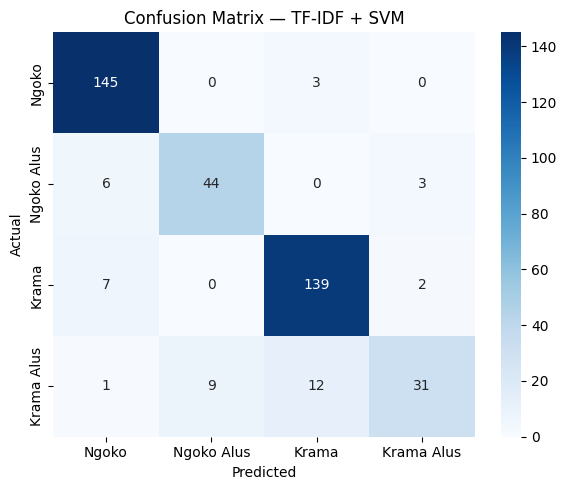

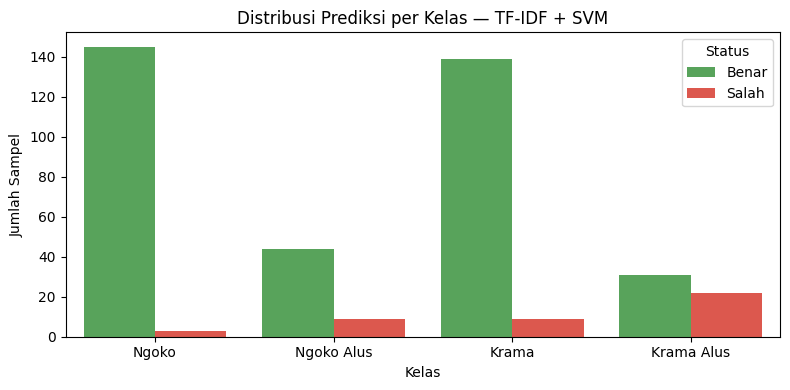

In [126]:
print_evaluation(y_test, y_pred_svm, "TF-IDF + SVM")
plot_confusion_matrix(y_test, y_pred_svm, "Confusion Matrix — TF-IDF + SVM")
plot_correct_incorrect(y_test, y_pred_svm, "Distribusi Prediksi per Kelas — TF-IDF + SVM")

### Analisis Hasil TF-IDF + SVM
#
Model TF-IDF + SVM menghasilkan akurasi sekitar **89%**. Analisis per kelas:
#
- **Ngoko (0)** — performa terbaik (F1 ~0.94), kosakata Ngoko sangat khas dan mudah dikenali
- **Krama (2)** — performa tinggi (F1 ~0.92), kosakata formal Krama juga cukup konsisten
- **Ngoko Alus (1)** — cukup baik (F1 ~0.83), terdapat beberapa kesalahan klasifikasi
- **Krama Alus (3)** — performa terendah (F1 ~0.70), recall rendah menunjukkan banyak kasus tidak terdeteksi
#
TF-IDF kesulitan membedakan tingkat tutur yang lebih halus karena hanya mengandalkan frekuensi kata, bukan makna.

---
## MODEL 2: FastText + BiLSTM
#
### Konsep FastText
#
FastText adalah metode *word embedding* yang merepresentasikan kata sebagai vektor dense dengan mempertimbangkan karakter (*subword n-gram*), bukan hanya kata utuh.
#
| Aspek | TF-IDF | FastText |
|---|---|---|
| Representasi | Sparse, berbasis frekuensi | Dense, berbasis makna |
| Hubungan kata | Tidak menangkap | Menangkap kemiripan semantik |
| Kata baru (OOV) | Tidak bisa | Bisa (via subword) |
#
**Cara kerja:**
1. Kata dipecah menjadi *character n-gram* (misal: `mangan` → `<ma, man, ang, nga, gan, an>`)
2. Setiap kata direpresentasikan sebagai vektor (misal: `mangan → [0.21, -0.13, 0.55, ...]`)
3. Kalimat direpresentasikan sebagai rata-rata vektor semua kata (*mean pooling*)
#
### Konsep BiLSTM + Attention
#
BiLSTM (*Bidirectional LSTM*) memproses urutan teks dari dua arah (maju dan mundur) untuk menangkap konteks lebih kaya. Mekanisme *attention* digunakan untuk memberi bobot lebih pada bagian teks yang paling informatif.

In [127]:
sentences = [text.split() for text in df["javanese_clean"]]

ft_model = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    hs=0,
    negative=10,
    epochs=30,
    min_n=2,
    max_n=5,
    seed=42
)

print(f"FastText training selesai")
print(f"Vocab size  : {len(ft_model.wv)}")
print(f"Vector size : {ft_model.vector_size}")

FastText training selesai
Vocab size  : 3497
Vector size : 100


### Konversi Kalimat ke Vektor
#
Setiap kalimat diubah menjadi satu vektor representatif menggunakan **mean pooling** — rata-rata dari semua vektor kata di kalimat tersebut. FastText menangani OOV secara otomatis melalui *character n-gram*.

In [128]:
def sentence_to_vector(sentence, model):
    words = sentence.split()
    if not words:
        return np.zeros(model.vector_size)
    vectors = np.array([model.wv[w] for w in words])
    return np.mean(vectors, axis=0)

X_train_vec = np.array([sentence_to_vector(s, ft_model) for s in X_train])
X_test_vec  = np.array([sentence_to_vector(s, ft_model) for s in X_test])

print(f"X_train_vec shape : {X_train_vec.shape}")
print(f"X_test_vec shape  : {X_test_vec.shape}")

X_train_vec shape : (1607, 100)
X_test_vec shape  : (402, 100)


### Persiapan DataLoader untuk BiLSTM
#
Vektor kalimat dikonversi ke tensor PyTorch dan dibungkus dalam `DataLoader`. BiLSTM membutuhkan input 3D `(batch, seq_len, input_size)`, sehingga dimensi sequence ditambahkan dengan `unsqueeze(1)`.

In [129]:
X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(X_test_vec,  dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

train_dataset_lstm = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_lstm  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=32, shuffle=True,  drop_last=False)
test_loader_lstm  = DataLoader(test_dataset_lstm,  batch_size=32, shuffle=False, drop_last=False)

class_weights_lstm = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights_lstm_tensor = torch.tensor(class_weights_lstm, dtype=torch.float32)
print("Class weights:", {label_map[le.classes_[i]]: round(w, 3) for i, w in enumerate(class_weights_lstm)})

Class weights: {'Ngoko': np.float64(0.676), 'Ngoko Alus': np.float64(1.913), 'Krama': np.float64(0.679), 'Krama Alus': np.float64(1.904)}


### Arsitektur BiLSTM + Attention
#
Model terdiri dari:
- **Batch Normalization** pada input untuk stabilisasi training
- **Stacked BiLSTM** (2 layer) untuk menangkap konteks dua arah
- **Self-Attention** untuk memilih bagian teks yang paling relevan
- **Classifier Head** dengan LayerNorm dan Dropout untuk regularisasi

In [130]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, 1)

    def forward(self, lstm_out):
        scores = self.attn(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = (lstm_out * weights).sum(dim=1)
        return context


class BiLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.bn_input = nn.BatchNorm1d(input_size)
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = Attention(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        batch, seq, feat = x.shape
        x = x.reshape(batch * seq, feat)
        x = self.bn_input(x)
        x = x.reshape(batch, seq, feat)
        lstm_out, _ = self.lstm(x)
        context = self.attention(lstm_out)
        context = self.dropout(context)
        return self.classifier(context)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

lstm_model = BiLSTMAttention(
    input_size=100, hidden_size=128, num_classes=num_classes,
    num_layers=2, dropout=0.3
).to(device)

trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Device: cuda
Trainable parameters: 664,909


### Training BiLSTM
#
Konfigurasi training:
- **Loss**: CrossEntropyLoss dengan class weight (menangani imbalanced data) + label smoothing 0.1
- **Optimizer**: AdamW dengan weight decay
- **Scheduler**: Cosine Annealing LR
- **Early Stopping**: berhenti jika tidak ada improvement selama 10 epoch

In [131]:
criterion_lstm = nn.CrossEntropyLoss(
    weight=class_weights_lstm_tensor.to(device), label_smoothing=0.1
)
optimizer_lstm = optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_lstm = optim.lr_scheduler.CosineAnnealingLR(optimizer_lstm, T_max=50, eta_min=1e-5)

epochs = 50
best_val_acc_lstm = 0.0
best_model_state_lstm = None
patience, patience_counter = 10, 0

for epoch in range(1, epochs + 1):
    lstm_model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader_lstm:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(lstm_model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        total_loss += loss.item()
    scheduler_lstm.step()

    lstm_model.eval()
    preds_ep, labels_ep = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_lstm:
            _, predicted = torch.max(lstm_model(X_batch.to(device)), 1)
            preds_ep.extend(predicted.cpu().numpy())
            labels_ep.extend(y_batch.numpy())

    val_acc = accuracy_score(labels_ep, preds_ep)

    if val_acc > best_val_acc_lstm:
        best_val_acc_lstm = val_acc
        best_model_state_lstm = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Loss: {total_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Best: {best_val_acc_lstm:.4f} | "
              f"LR: {scheduler_lstm.get_last_lr()[0]:.6f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping di epoch {epoch}. Best val acc: {best_val_acc_lstm:.4f}")
        break

Epoch   1/50 | Loss: 43.9262 | Val Acc: 0.8955 | Best: 0.8955 | LR: 0.000999
Epoch   5/50 | Loss: 32.4446 | Val Acc: 0.9378 | Best: 0.9378 | LR: 0.000976
Epoch  10/50 | Loss: 30.5088 | Val Acc: 0.9279 | Best: 0.9378 | LR: 0.000905
Epoch  15/50 | Loss: 28.6994 | Val Acc: 0.9378 | Best: 0.9378 | LR: 0.000796

Early stopping di epoch 15. Best val acc: 0.9378


### Hasil Evaluasi — FastText + BiLSTM

EVALUASI — FastText + BiLSTM Attention
Accuracy : 0.9378

Classification Report:
              precision    recall  f1-score   support

       Ngoko       0.97      0.96      0.96       148
  Ngoko Alus       0.86      0.94      0.90        53
       Krama       0.95      0.95      0.95       148
  Krama Alus       0.90      0.83      0.86        53

    accuracy                           0.94       402
   macro avg       0.92      0.92      0.92       402
weighted avg       0.94      0.94      0.94       402



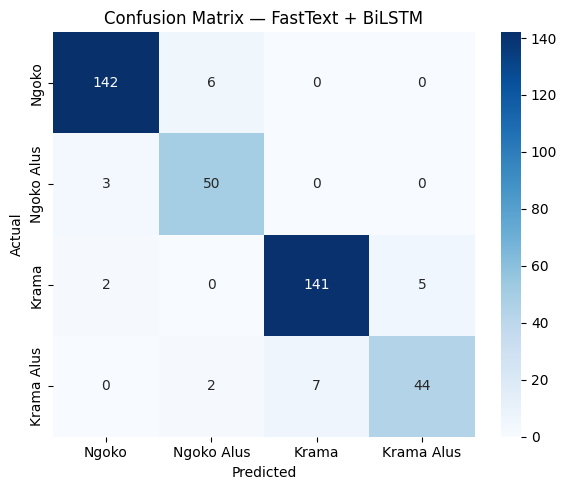

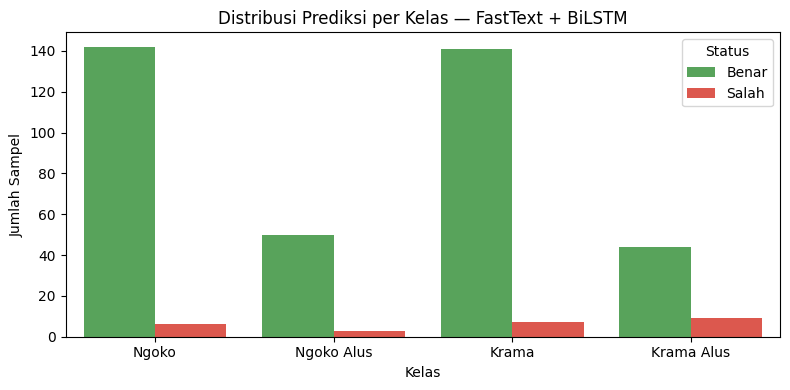

In [132]:
lstm_model.load_state_dict(best_model_state_lstm)
lstm_model.eval()

y_pred_lstm, y_true_lstm = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_lstm:
        _, predicted = torch.max(lstm_model(X_batch.to(device)), 1)
        y_pred_lstm.extend(predicted.cpu().numpy())
        y_true_lstm.extend(y_batch.numpy())

print_evaluation(y_true_lstm, y_pred_lstm, "FastText + BiLSTM Attention")
plot_confusion_matrix(y_true_lstm, y_pred_lstm, "Confusion Matrix — FastText + BiLSTM")
plot_correct_incorrect(y_true_lstm, y_pred_lstm, "Distribusi Prediksi per Kelas — FastText + BiLSTM")

---
## MODEL 3: Javanese BERT (Contextual Embedding)
#
### Konsep Contextual Embedding
#
Berbeda dengan FastText yang menghasilkan satu vektor tetap per kata, BERT menghasilkan representasi **kontekstual** — vektor kata berubah sesuai konteks kalimatnya.
#
Model yang digunakan: **`w11wo/javanese-roberta-small`** — RoBERTa yang di-pretrain khusus pada korpus Bahasa Jawa.
#
**Arsitektur fine-tuning:**
- Token `[CLS]` diambil sebagai representasi seluruh kalimat
- Classifier head dengan bottleneck: `hidden → hidden/2 → num_classes`
- GELU activation dan LayerNorm untuk stabilitas

In [133]:
MODEL_NAME = "w11wo/javanese-roberta-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Model      : {MODEL_NAME}")
print(f"Vocab size : {tokenizer.vocab_size}")

sample = X_train[0]
tokens = tokenizer(sample, truncation=True, max_length=128)
print(f"\nContoh teks   : {sample[:80]}...")
print(f"Panjang token : {len(tokens['input_ids'])}")

Model      : w11wo/javanese-roberta-small
Vocab size : 50265

Contoh teks   : kambengan aben sawung ing dhusun kula dipungroyok polisi...
Panjang token : 16


### Dataset dan DataLoader untuk BERT
#
Setiap kalimat di-tokenisasi dengan padding ke panjang maksimum 128 token. `attention_mask` digunakan agar model tidak memperhatikan token padding.

In [134]:
MAX_LEN = 128

class JavaneseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset_bert = JavaneseDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset_bert  = JavaneseDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
test_loader_bert  = DataLoader(test_dataset_bert,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader_bert)}")
print(f"Test batches  : {len(test_loader_bert)}")

Train batches : 101
Test batches  : 26


### Arsitektur Javanese BERT Classifier
#
Model fine-tuning terdiri dari:
- **BERT backbone** (`w11wo/javanese-roberta-small`) sebagai feature extractor
- **[CLS] token** diambil dari `last_hidden_state[:, 0, :]` sebagai representasi kalimat
- **Classifier head**: Linear → LayerNorm → GELU → Dropout → Linear

In [135]:
class JavaneseBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        print(f"BERT hidden size: {hidden_size}")
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)


bert_model = JavaneseBERTClassifier(MODEL_NAME, num_classes=num_classes, dropout=0.3).to(device)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: w11wo/javanese-roberta-small
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT hidden size: 768
Total params    : 124,943,236
Trainable params: 124,943,236


### Konfigurasi Training BERT
#
Fine-tuning BERT menggunakan strategi **differential learning rate**:
- BERT backbone: `lr = 2e-5` (fine-tuning halus)
- Classifier head: `lr = 1e-4` (learning lebih agresif)
#
Scheduler menggunakan **linear warmup** (10% dari total steps) untuk menghindari perubahan bobot yang terlalu besar di awal training.

In [136]:
class_weights_bert = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights_bert_tensor = torch.tensor(class_weights_bert, dtype=torch.float32).to(device)

criterion_bert = nn.CrossEntropyLoss(weight=class_weights_bert_tensor, label_smoothing=0.1)

optimizer_bert = torch.optim.AdamW([
    {'params': list(bert_model.bert.parameters()),        'lr': 2e-5, 'weight_decay': 0.01},
    {'params': list(bert_model.classifier.parameters()),  'lr': 1e-4, 'weight_decay': 0.01}
])

EPOCHS_BERT   = 20
total_steps   = len(train_loader_bert) * EPOCHS_BERT
warmup_steps  = int(0.1 * total_steps)

scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print("Class weights:", {label_map[le.classes_[i]]: round(w, 3) for i, w in enumerate(class_weights_bert)})

Total steps  : 2020
Warmup steps : 202
Class weights: {'Ngoko': np.float64(0.676), 'Ngoko Alus': np.float64(1.913), 'Krama': np.float64(0.679), 'Krama Alus': np.float64(1.904)}


### Training Javanese BERT
#
Fine-tuning dilakukan selama maksimum 10 epoch dengan early stopping (patience=5). Gradient clipping (`max_norm=1.0`) diterapkan untuk menjaga stabilitas training BERT.

In [137]:
best_val_acc_bert    = 0.0
best_model_state_bert = None
patience_bert, patience_counter_bert = 5, 0

print("Mulai fine-tuning Javanese BERT...\n")
print(f"{'Epoch':>6} | {'Loss':>10} | {'Val Acc':>8} | {'Best':>8} | {'Time':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS_BERT + 1):
    t0 = time.time()

    bert_model.train()
    total_loss = 0.0
    for batch in train_loader_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer_bert.zero_grad()
        loss = criterion_bert(bert_model(input_ids, attention_mask), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_bert)

    bert_model.eval()
    preds_ep, labels_ep = [], []
    with torch.no_grad():
        for batch in test_loader_bert:
            logits = bert_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            _, preds = torch.max(logits, dim=1)
            preds_ep.extend(preds.cpu().numpy())
            labels_ep.extend(batch['labels'].numpy())

    val_acc = accuracy_score(labels_ep, preds_ep)
    elapsed = time.time() - t0

    if val_acc > best_val_acc_bert:
        best_val_acc_bert = val_acc
        best_model_state_bert = {k: v.clone() for k, v in bert_model.state_dict().items()}
        patience_counter_bert = 0
        marker = " ◀ best"
    else:
        patience_counter_bert += 1
        marker = ""

    print(f"{epoch:>6} | {avg_loss:>10.4f} | {val_acc:>8.4f} | {best_val_acc_bert:>8.4f} | {elapsed:>6.1f}s{marker}")

    if patience_counter_bert >= patience_bert:
        print(f"\nEarly stopping di epoch {epoch}.")
        break

print(f"\nBest val accuracy: {best_val_acc_bert:.4f}")

Mulai fine-tuning Javanese BERT...

 Epoch |       Loss |  Val Acc |     Best |    Time
----------------------------------------------------
     1 |     1.3811 |   0.5846 |   0.5846 |   37.2s ◀ best
     2 |     0.9731 |   0.7512 |   0.7512 |   38.6s ◀ best
     3 |     0.7486 |   0.8881 |   0.8881 |   40.2s ◀ best
     4 |     0.6375 |   0.9030 |   0.9030 |   40.1s ◀ best
     5 |     0.5879 |   0.8731 |   0.9030 |   40.0s
     6 |     0.5462 |   0.9055 |   0.9055 |   40.1s ◀ best
     7 |     0.5261 |   0.8930 |   0.9055 |   40.0s
     8 |     0.4956 |   0.8980 |   0.9055 |   40.1s
     9 |     0.4845 |   0.9279 |   0.9279 |   40.1s ◀ best
    10 |     0.4759 |   0.9229 |   0.9279 |   40.0s
    11 |     0.4603 |   0.9229 |   0.9279 |   40.0s
    12 |     0.4593 |   0.9254 |   0.9279 |   40.0s
    13 |     0.4480 |   0.9328 |   0.9328 |   40.0s ◀ best
    14 |     0.4453 |   0.9204 |   0.9328 |   40.0s
    15 |     0.4448 |   0.9328 |   0.9328 |   40.0s
    16 |     0.4452 |   0.9254

### Hasil Evaluasi — Javanese BERT

EVALUASI — Javanese BERT (w11wo/javanese-roberta-small)
Accuracy : 0.9328

Classification Report:
              precision    recall  f1-score   support

       Ngoko       0.95      0.97      0.96       148
  Ngoko Alus       0.82      0.87      0.84        53
       Krama       0.96      0.97      0.97       148
  Krama Alus       0.93      0.79      0.86        53

    accuracy                           0.93       402
   macro avg       0.92      0.90      0.91       402
weighted avg       0.93      0.93      0.93       402



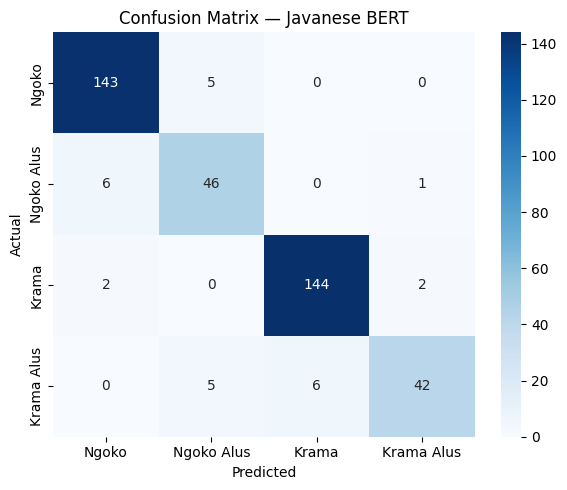

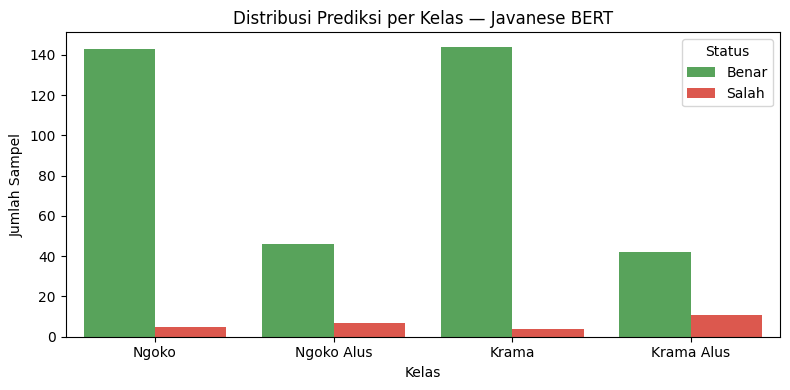

In [138]:
bert_model.load_state_dict(best_model_state_bert)
bert_model.eval()

y_pred_bert, y_true_bert = [], []
with torch.no_grad():
    for batch in test_loader_bert:
        logits = bert_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        _, preds = torch.max(logits, dim=1)
        y_pred_bert.extend(preds.cpu().numpy())
        y_true_bert.extend(batch['labels'].numpy())

print_evaluation(y_true_bert, y_pred_bert, "Javanese BERT (w11wo/javanese-roberta-small)")
plot_confusion_matrix(y_true_bert, y_pred_bert, "Confusion Matrix — Javanese BERT")
plot_correct_incorrect(y_true_bert, y_pred_bert, "Distribusi Prediksi per Kelas — Javanese BERT")

---
## 8. Perbandingan Akhir Semua Model
#
Ringkasan performa ketiga pendekatan pada data uji:
#
| Model | Pendekatan | Kelebihan | Kekurangan |
|---|---|---|---|
| TF-IDF + SVM | Klasik | Cepat, mudah diinterpretasi | Tidak menangkap makna |
| FastText + BiLSTM | Word Embedding | Memahami kemiripan kata, handle OOV | Tidak menangkap konteks penuh |
| Javanese BERT | Contextual Embedding | Konteks penuh, pretrained Bahasa Jawa | Berat, butuh resource lebih |

RINGKASAN AKURASI SEMUA MODEL
  TF-IDF + SVM          : 0.8930 (89.30%)
  FastText + BiLSTM     : 0.9378 (93.78%)
  Javanese BERT         : 0.9328 (93.28%)


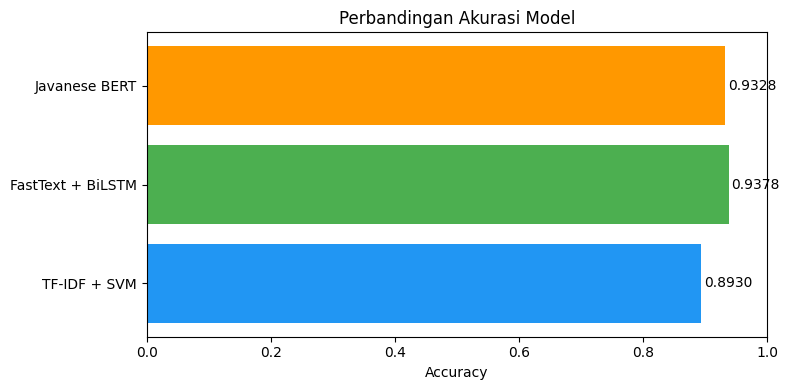

In [139]:
results_summary = {
    "TF-IDF + SVM":        accuracy_score(y_test, y_pred_svm),
    "FastText + BiLSTM":   accuracy_score(y_true_lstm, y_pred_lstm),
    "Javanese BERT":       accuracy_score(y_true_bert, y_pred_bert),
}

print("=" * 45)
print("RINGKASAN AKURASI SEMUA MODEL")
print("=" * 45)
for model_name, acc in results_summary.items():
    print(f"  {model_name:<22}: {acc:.4f} ({acc*100:.2f}%)")
print("=" * 45)

plt.figure(figsize=(8, 4))
bars = plt.barh(list(results_summary.keys()), list(results_summary.values()),
                color=["#2196F3", "#4CAF50", "#FF9800"])
plt.xlabel("Accuracy")
plt.title("Perbandingan Akurasi Model")
plt.xlim(0, 1.0)
for bar, val in zip(bars, results_summary.values()):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()